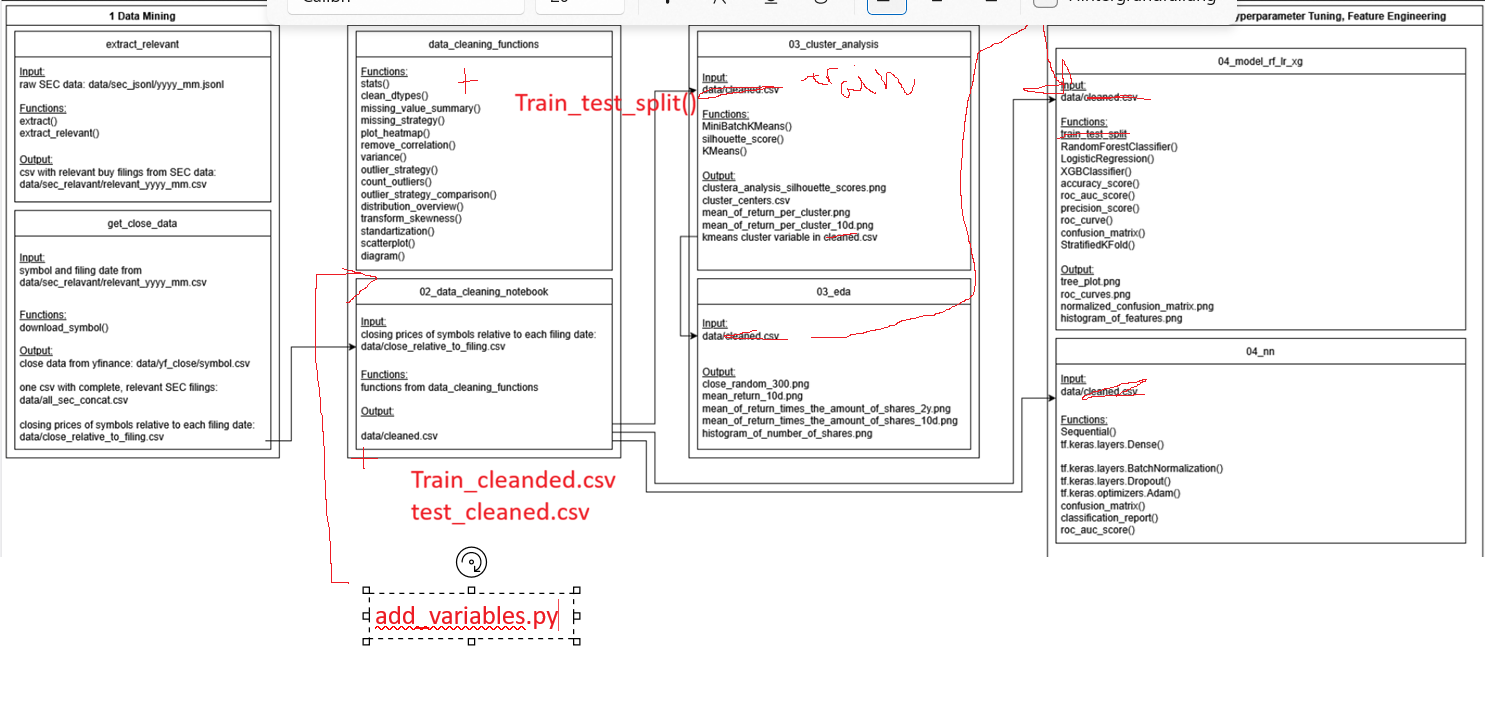

wo target lol -> ich behalte die ganzen tages preisewerte und amch die target später in 04 model 



target schon bei add variables, dann checken ob bools richtig ankommen und weiter Memory error beim outleiers fixen

statt die daten für jeden tag mitzuschleppen, gleich targets berechenen und dann nur diese targets joinen


# Data Cleaning


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import itertools
from scipy.stats import boxcox, skew, zscore
import sys
from pathlib import Path
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split

project_root = Path().resolve().parent
sys.path.append(str(project_root / "src/02_data_preperation"))

from data_cleaning import missing_strategy, plot_heatmap, skewness_overview

In [3]:
inner_close_sec_uncleaned = pd.read_csv(project_root / "data/inner_close_sec_uncleaned.csv")


In [4]:
inner_close_sec_uncleaned


,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,postTransactionAmounts.sharesOwnedFollowingTransaction,ownershipNature.directOrIndirectOwnership,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,...,740,741,742,743,744,745,746,747,748,749
0,ANTP,INZER DEBORAH,2009-01-29,1000.0,2.5000,3000.0,D,False,True,False,...,3.720000,3.830000,3.710100,3.880000,3.880000,3.880000,3.819900,3.650000,3.630000,3.640000
1,BLK,MERRILL LYNCH CO INC,2009-01-22,1000.0,106.0499,2332450.0,D,False,False,True,...,136.782059,134.341812,133.784454,132.105515,132.105515,132.105515,133.227020,135.517731,135.687744,136.428650
2,HBNC,NEFF JAMES D,2009-01-30,6000.0,12.5000,42700.0,D,False,True,False,...,3.501738,3.576777,3.600539,3.600539,3.600539,3.611793,3.611793,3.626802,3.618046,3.629302
3,HBNC,NEFF JAMES D,2009-01-30,4000.0,12.4975,46700.0,D,False,True,False,...,3.501738,3.576777,3.600539,3.600539,3.600539,3.611793,3.611793,3.626802,3.618046,3.629302
4,WLFC,JACOBS SY,2009-01-28,1910.0,8.6000,659651.0,I,False,False,True,...,13.063982,13.073694,13.073694,13.229106,13.015418,13.015418,13.015418,13.015418,12.986280,13.025130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252714,TPL,STAHL MURRAY,2023-12-29,3.0,1572.4500,198486.0,I,True,False,False,...,169.975632,169.975632,169.975632,169.975632,169.975632,169.975632,169.975632,169.975632,169.975632,169.975632
252715,NBBK,AYOUB PAUL J,2023-12-28,5000.0,14.0000,5000.0,I,True,False,False,...,13.301009,13.301009,13.301009,13.301009,13.301009,13.301009,13.301009,13.301009,13.301009,13.301009
252716,MPA,SABA CAPITAL MANAGEMENT LP,2023-12-28,2064.0,11.5700,1899928.0,I,False,False,True,...,10.158413,10.158413,10.158413,10.158413,10.158413,10.158413,10.158413,10.158413,10.158413,10.158413
252717,ECAT,SABA CAPITAL MANAGEMENT LP,2023-12-28,299702.0,16.3700,24012511.0,I,False,False,True,...,10.604922,10.604922,10.604922,10.604922,10.604922,10.604922,10.604922,10.604922,10.604922,10.604922


In [5]:
inner_close_sec_uncleaned.isnull().sum()

issuer.tradingSymbol         0
reportingOwner.name          0
transactionDate              0
amounts.shares               0
amounts.pricePerShare        0
                         ...  
745                      11094
746                      11093
747                      11092
748                      11090
749                      11088
Length: 772, dtype: int64

In [6]:
crtf_missing_removed = missing_strategy(inner_close_sec_uncleaned,
                      default_missing_strategy="delete",
                      except_replace_0=[],
                      except_replace_mean=[],
                      except_delete=[])
crtf_missing_removed

,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,postTransactionAmounts.sharesOwnedFollowingTransaction,ownershipNature.directOrIndirectOwnership,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,...,740,741,742,743,744,745,746,747,748,749
0,ANTP,INZER DEBORAH,2009-01-29,1000.0,2.5000,3000.0,D,False,True,False,...,3.720000,3.830000,3.710100,3.880000,3.880000,3.880000,3.819900,3.650000,3.630000,3.640000
1,BLK,MERRILL LYNCH CO INC,2009-01-22,1000.0,106.0499,2332450.0,D,False,False,True,...,136.782059,134.341812,133.784454,132.105515,132.105515,132.105515,133.227020,135.517731,135.687744,136.428650
2,HBNC,NEFF JAMES D,2009-01-30,6000.0,12.5000,42700.0,D,False,True,False,...,3.501738,3.576777,3.600539,3.600539,3.600539,3.611793,3.611793,3.626802,3.618046,3.629302
3,HBNC,NEFF JAMES D,2009-01-30,4000.0,12.4975,46700.0,D,False,True,False,...,3.501738,3.576777,3.600539,3.600539,3.600539,3.611793,3.611793,3.626802,3.618046,3.629302
4,WLFC,JACOBS SY,2009-01-28,1910.0,8.6000,659651.0,I,False,False,True,...,13.063982,13.073694,13.073694,13.229106,13.015418,13.015418,13.015418,13.015418,12.986280,13.025130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252714,TPL,STAHL MURRAY,2023-12-29,3.0,1572.4500,198486.0,I,True,False,False,...,169.975632,169.975632,169.975632,169.975632,169.975632,169.975632,169.975632,169.975632,169.975632,169.975632
252715,NBBK,AYOUB PAUL J,2023-12-28,5000.0,14.0000,5000.0,I,True,False,False,...,13.301009,13.301009,13.301009,13.301009,13.301009,13.301009,13.301009,13.301009,13.301009,13.301009
252716,MPA,SABA CAPITAL MANAGEMENT LP,2023-12-28,2064.0,11.5700,1899928.0,I,False,False,True,...,10.158413,10.158413,10.158413,10.158413,10.158413,10.158413,10.158413,10.158413,10.158413,10.158413
252717,ECAT,SABA CAPITAL MANAGEMENT LP,2023-12-28,299702.0,16.3700,24012511.0,I,False,False,True,...,10.604922,10.604922,10.604922,10.604922,10.604922,10.604922,10.604922,10.604922,10.604922,10.604922


In [9]:
crtf_str_removed = crtf_missing_removed.drop(columns=["issuer.tradingSymbol", "reportingOwner.name", "transactionDate", "ownershipNature.directOrIndirectOwnership"])

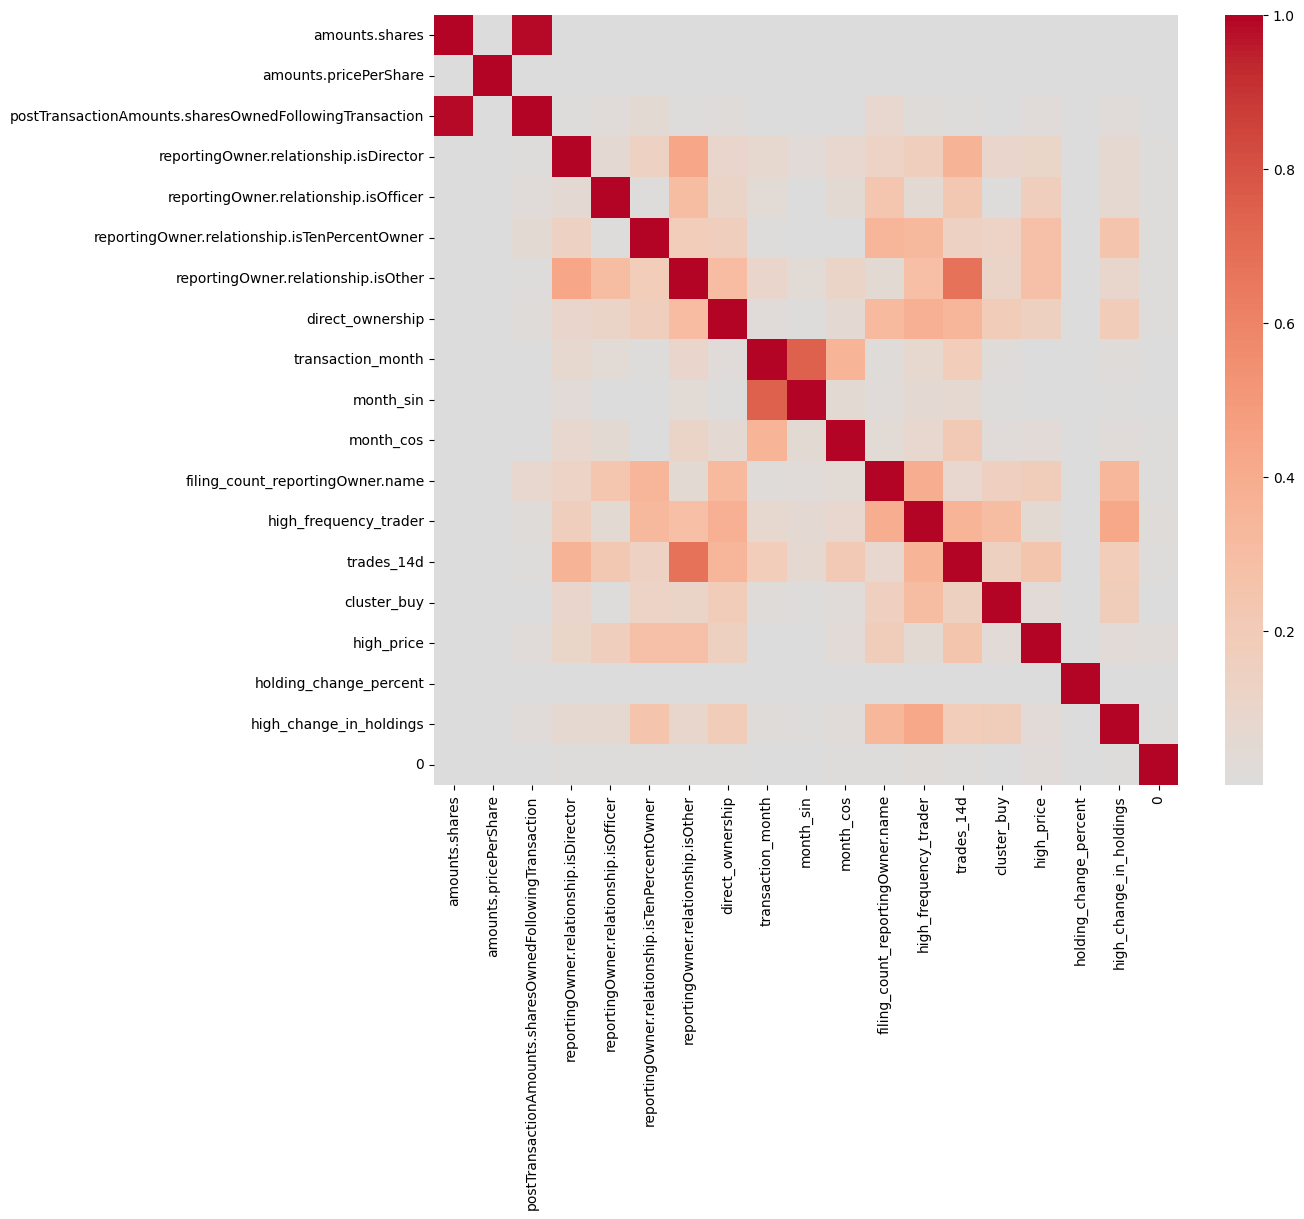

In [16]:
corr_mat_subset = crtf_str_removed.iloc[:, 0:19]

plot_heatmap(corr_mat_subset)
crtf_mhighcor_removed = crtf_str_removed.drop(columns="postTransactionAmounts.sharesOwnedFollowingTransaction")

In [17]:
crtf_mhighcor_removed["target"] = (
    crtf_mhighcor_removed['5'] >
    crtf_mhighcor_removed['0']
    ).astype('int8')
crtf_mhighcor_removed["target"].sum()

np.int64(142110)

In [29]:
crtf_mhighcor_removed.dtypes

amounts.shares                                   float64
amounts.pricePerShare                            float64
reportingOwner.relationship.isDirector              bool
reportingOwner.relationship.isOfficer               bool
reportingOwner.relationship.isTenPercentOwner       bool
                                                  ...   
746                                              float64
747                                              float64
748                                              float64
749                                              float64
target                                              int8
Length: 768, dtype: object

In [ ]:
# saving memory
integer = ["amounts.shares", "transaction_month" , "filing_count_reportingOwner.name", ]
bools = ["direct_ownership", ""]
floats = ["amounts.pricePerShare", "month_sin", "month_cos"]

In [ ]:
y = crtf_mhighcor_removed['target']
x_columns = [col for col in crtf_mhighcor_removed.columns if col != "target"]
X = crtf_mhighcor_removed[x_columns]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=420)

In [28]:
X_train_cols_without_days = [c for c in X_train if not (str(c).isdigit() and 0 <= int(c) <= 749 and not type(bool))]
X_test_cols_without_days = [c for c in X_test if not (str(c).isdigit() and 0 <= int(c) <= 749 and not type(bool))]
X_train_without_days = X_train[X_train_cols_without_days]
X_test_without_days = X_test[X_test_cols_without_days]
Q1 = X_train_without_days.quantile(0.25)
Q3 = X_train_without_days.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

for df in X_train_without_days, X_test_without_days:
    outlier_counts = ((df < lower) | (df > upper)).sum()
    print(outlier_counts)

MemoryError: Unable to allocate 456. MiB for an array with shape (756, 79009) and data type float64

In [7]:
mask = ~((df_numeric < lower) | (df_numeric > upper)).any(axis=1)

crtf_outlier_removed = crtf_mhighcor_removed[mask]
crtf_outlier_removed

,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,ownershipNature.directOrIndirectOwnership,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,reportingOwner.relationship.isOther,...,740,741,742,743,744,745,746,747,748,749
3,HBNC,NEFF JAMES D,2009-01-30,4000.0,12.4975,D,False,True,False,False,...,3.501738,3.576777,3.600539,3.600539,3.600539,3.611793,3.611793,3.626802,3.618046,3.629302
4,WLFC,JACOBS SY,2009-01-28,1910.0,8.6000,I,False,False,True,False,...,13.063982,13.073694,13.073694,13.229106,13.015418,13.015418,13.015418,13.015418,12.986280,13.025130
5,WLFC,JACOBS SY,2009-01-29,613.0,8.6600,I,False,False,True,False,...,13.073694,13.073694,13.229106,13.015418,13.015418,13.015418,13.015418,12.986280,13.025130,13.034844
6,WLFC,JACOBS SY,2009-01-30,808.0,8.5400,I,False,False,True,False,...,13.073694,13.229106,13.015418,13.015418,13.015418,13.015418,12.986280,13.025130,13.034844,13.073694
19,HXL,HENNEMUTH ROBERT,2009-01-30,400.0,8.0400,D,False,True,False,False,...,18.499733,18.729713,18.941296,18.941296,18.941296,18.987293,18.959692,18.895298,18.922897,19.033287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252705,SPE,GOLDSTEIN PHILLIP,2023-12-28,44.0,11.7500,D,True,True,False,False,...,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709
252706,SPE,GOLDSTEIN PHILLIP,2023-12-28,1319.0,11.7800,D,True,True,False,False,...,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709
252707,SFBC,STILWELL JOSEPH,2023-12-28,7.0,38.7500,I,False,False,True,False,...,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849
252708,SFBC,STILWELL JOSEPH,2023-12-29,404.0,39.0000,I,False,False,True,False,...,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849


In [8]:
df_non_str = crtf_outlier_removed[non_str]
variances = df_non_str.var(skipna=True, ddof=1)
variances

amounts.shares                                   6.880135e+06
amounts.pricePerShare                            2.334086e+02
reportingOwner.relationship.isDirector           2.257242e-01
reportingOwner.relationship.isOfficer            2.417384e-01
reportingOwner.relationship.isTenPercentOwner    1.759444e-01
reportingOwner.relationship.isOther              5.670625e-02
direct_ownership                                 2.055571e-01
transaction_month                                1.117388e+01
month_sin                                        5.127612e-01
month_cos                                        4.852629e-01
filing_count_reportingOwner.name                 5.453524e+04
high_frequency_trader                            2.495720e-01
trades_14d                                       1.843921e+02
cluster_buy                                      0.000000e+00
high_price                                       2.497604e-01
holding_change_percent                           7.207688e+00
high_cha

In [9]:
crtf_lowvar_removed = crtf_outlier_removed.drop(columns=["cluster_buy", "reportingOwner.relationship.isOther"])
non_str.remove("cluster_buy")
non_str.remove("reportingOwner.relationship.isOther")
crtf_lowvar_removed
#crtf_missing_removed.to_csv(project_root / "data/raw.csv")

,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,ownershipNature.directOrIndirectOwnership,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,direct_ownership,...,740,741,742,743,744,745,746,747,748,749
3,HBNC,NEFF JAMES D,2009-01-30,4000.0,12.4975,D,False,True,False,1,...,3.501738,3.576777,3.600539,3.600539,3.600539,3.611793,3.611793,3.626802,3.618046,3.629302
4,WLFC,JACOBS SY,2009-01-28,1910.0,8.6000,I,False,False,True,0,...,13.063982,13.073694,13.073694,13.229106,13.015418,13.015418,13.015418,13.015418,12.986280,13.025130
5,WLFC,JACOBS SY,2009-01-29,613.0,8.6600,I,False,False,True,0,...,13.073694,13.073694,13.229106,13.015418,13.015418,13.015418,13.015418,12.986280,13.025130,13.034844
6,WLFC,JACOBS SY,2009-01-30,808.0,8.5400,I,False,False,True,0,...,13.073694,13.229106,13.015418,13.015418,13.015418,13.015418,12.986280,13.025130,13.034844,13.073694
19,HXL,HENNEMUTH ROBERT,2009-01-30,400.0,8.0400,D,False,True,False,1,...,18.499733,18.729713,18.941296,18.941296,18.941296,18.987293,18.959692,18.895298,18.922897,19.033287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252705,SPE,GOLDSTEIN PHILLIP,2023-12-28,44.0,11.7500,D,True,True,False,1,...,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709
252706,SPE,GOLDSTEIN PHILLIP,2023-12-28,1319.0,11.7800,D,True,True,False,1,...,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709
252707,SFBC,STILWELL JOSEPH,2023-12-28,7.0,38.7500,I,False,False,True,0,...,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849
252708,SFBC,STILWELL JOSEPH,2023-12-29,404.0,39.0000,I,False,False,True,0,...,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849


In [10]:
skewness_overview(crtf_lowvar_removed[non_str])

,Row,original,log(x),log1p,sqrt,boxcox,power_transform,row
0,amounts.shares,1.967,-0.682,-0.518,1.028,-0.055,-0.054,NaN
1,amounts.pricePerShare,1.737,-0.15,-0.013,0.733,-0.018,-0.002,NaN
2,NaN,-,-,-,-,-,-,reportingOwner.relationship.isDirector
3,NaN,-,-,-,-,-,-,reportingOwner.relationship.isOfficer
4,NaN,-,-,-,-,-,-,reportingOwner.relationship.isTenPercentOwner
5,direct_ownership,-0.93,not applicable because 0 or negative value,-0.93,-0.93,not calculable because values smaller then 0,-0.93,NaN
6,transaction_month,0.033,-0.951,-0.688,-0.384,-0.184,-0.144,NaN
7,month_sin,-0.004,not applicable because 0 or negative value,not calculable because values smaller then -1,not calculable because of values smaller then 0,not calculable because values smaller then 0,-0.001,NaN
8,month_cos,0.137,not applicable because 0 or negative value,not calculable because values smaller then -1,not calculable because of values smaller then 0,not calculable because values smaller then 0,0.051,NaN
9,filing_count_reportingOwner.name,3.133,-0.144,0.026,1.636,-0.009,0.002,NaN


In [11]:
crtf_skewness = crtf_lowvar_removed
crtf_skewness["boxcox_amounts_shares"],_ = boxcox(crtf_skewness["amounts.shares"])
crtf_skewness["boxcox_amounts.pricePerShare"],_ = boxcox(crtf_skewness["amounts.pricePerShare"])
pt = PowerTransformer(method='yeo-johnson', standardize=True)
crtf_skewness["powertransform_holding_change_percent"] = (
    pt.fit_transform(crtf_skewness["holding_change_percent"].values.reshape(-1, 1))
)


In [12]:
crtf_skewness

,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,ownershipNature.directOrIndirectOwnership,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,direct_ownership,...,743,744,745,746,747,748,749,boxcox_amounts_shares,boxcox_amounts.pricePerShare,powertransform_holding_change_percent
3,HBNC,NEFF JAMES D,2009-01-30,4000.0,12.4975,D,False,True,False,1,...,3.600539,3.600539,3.611793,3.611793,3.626802,3.618046,3.629302,14.810847,2.800167,1.682722
4,WLFC,JACOBS SY,2009-01-28,1910.0,8.6000,I,False,False,True,0,...,13.229106,13.015418,13.015418,13.015418,13.015418,12.986280,13.025130,12.763522,2.349076,-0.534718
5,WLFC,JACOBS SY,2009-01-29,613.0,8.6600,I,False,False,True,0,...,13.015418,13.015418,13.015418,13.015418,12.986280,13.025130,13.034844,9.971760,2.357344,-0.949839
6,WLFC,JACOBS SY,2009-01-30,808.0,8.5400,I,False,False,True,0,...,13.015418,13.015418,13.015418,12.986280,13.025130,13.034844,13.073694,10.613207,2.340755,-0.879243
19,HXL,HENNEMUTH ROBERT,2009-01-30,400.0,8.0400,D,False,True,False,1,...,18.941296,18.941296,18.987293,18.959692,18.895298,18.922897,19.033287,9.024040,2.269244,1.074058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252705,SPE,GOLDSTEIN PHILLIP,2023-12-28,44.0,11.7500,D,True,True,False,1,...,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,4.873516,2.724795,-0.828549
252706,SPE,GOLDSTEIN PHILLIP,2023-12-28,1319.0,11.7800,D,True,True,False,1,...,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,11.808925,2.727904,1.346064
252707,SFBC,STILWELL JOSEPH,2023-12-28,7.0,38.7500,I,False,False,True,0,...,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,2.210827,4.251506,-1.188667
252708,SFBC,STILWELL JOSEPH,2023-12-29,404.0,39.0000,I,False,False,True,0,...,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,9.045543,4.260137,-0.732465


In [13]:
scale_cols = ["filing_count_reportingOwner.name", "trades_14d"]
crtf_scaled = crtf_skewness
for c in scale_cols:
    new_name = "scaled_" + c
    crtf_scaled[new_name] = zscore(crtf_skewness[c])

In [14]:
crtf_scaled.to_csv(project_root / "data/cleaned.csv", index=False)